<p style='font-weight:bold;'><font size=6 color='black'>Predicting Company Bankruptcy</font></p>

<p style='font-weight:bold;'><font size=4 color='black'>Application of Machine Learning Algorithms on Data from NYSE/NASDAQ and Taiwan Stock Exchange</font></p>

<div style="color:black;
           display:fill;
           border-radius:5px;
           background-color:#ADD8E6;
           font-size:100%;
           letter-spacing:0.5px">

<p style="padding: 1px;
              color:white;">

    <p style='font-weight:bold;'>&nbsp; tl;dr? Here is the summary:</p><br>

&nbsp; 1.  Due to the class imbalance between being bankrupt and not being bankrupt, the **Synthetic Minority Oversampling Technique (SMOTE) was applied, which improved the prediction accuracy and precision of the test datasets. <br>
<br>
&nbsp; 2.In the efforts to improve bankruptcy detection, I made a thoughtful decision to **prioritize the recall rate over accuracy (contradicting with what many others have done) for model performance evaluation**, to minimize false negatives, which is vital in financial analysis, where missing critical bankruptcy cases can be costly! <br>
<br>
&nbsp; 3. **Among all 7 algorithms using the NASDAQ data, accuracy and precision were both highest in Random Forest, followed by KNN and SVM**, with results being {RF:{Accuracy:0.89, Precision:0.88}, KNN:{ Accuracy:0.82, Precision:0.87}, SVM:{ Accuracy:0.82, Precision:0.86}}. <br>
<br>
&nbsp; 4. In NASDAQ data, **if taking computation cost, total computation time in this case into consideration, KNN can be considered outperforming random forest**, as it took KNN 7.1sec to conclude the results while random forest took 70mins. Details can be found in Table 1<br>
<br>
&nbsp; 5. In Taiwan Exchange Stock data, **KNN combined with non-linear PCA outperformed all other models**, indicating that these features are non-linearly seperatable. Details can be found in Table 2 <br>
<br>
&nbsp; 6. **Further improvements**, including outlier removal techniques, predictor reduction, and exploration of unsupervised models, will refine the predictions. Addressing imbalanced data and fine-tuning model selection through sample scenarios will also contribute to more robust and relevant bankruptcy predictions, empowering better decision-making in this dynamic landscape <br>
<br>
</p>
</div>

In [5]:
print("Table 1: US Company Bankruptcy Prediction")
results_dict={'Time':['7.1s','70m','17s','562m','2.3s','51m','350m'],\
              'Accuracy':[0.82,0.89,0.62,0.82,0.24,0.76,0.81],\
             'Precision':[0.87,0.88,0.89,0.86,0.86,0.88,0.88],\
             'Recall':[0.82,0.89,0.62,0.82,0.24,0.76,0.81],\
             'F1 Score':[0.84,0.89,0.70,0.84,0.31,0.81,0.84]}
US_results=pd.DataFrame.from_dict(results_dict)
algorithms=['KNN', 'Random Forst','Logistic Regression',\
                        'SVM','Naive Bayes','Neural Networks','Decision Tree']
US_results = US_results.set_index(pd.Index(algorithms))
display(US_results)

Table 1: US Company Bankruptcy Prediction


,Time,Accuracy,Precision,Recall,F1 Score
KNN,7.1s,0.82,0.87,0.82,0.84
Random Forst,70m,0.89,0.88,0.89,0.89
Logistic Regression,17s,0.62,0.89,0.62,0.70
SVM,562m,0.82,0.86,0.82,0.84
Naive Bayes,2.3s,0.24,0.86,0.24,0.31
Neural Networks,51m,0.76,0.88,0.76,0.81
Decision Tree,350m,0.81,0.88,0.81,0.84


In [6]:
print("Table 2. Taiwan Area Company Bankruptcy Prediction")
results_dict={'Accuracy':[0.79,0.89,0.90,0.97,0.97],\
             'Precision':[0.96,0.97,0.95,0.95,0.95],\
             'Recall':[0.79,0.89,0.91,0.97,0.97],\
             'F1 Score':[0.86,0.92,0.93,0.97,0.96]}
Taiwan_results=pd.DataFrame.from_dict(results_dict)
algorithms=['KNN','KNN with Feature Extraction','KNN with Linear PCA',\
            'KNN with Sigmoid PCA','KNN with rbf PCA']
Taiwan_results = Taiwan_results.set_index(pd.Index(algorithms))
display(Taiwan_results)


Table 2. Taiwan Area Company Bankruptcy Prediction


,Accuracy,Precision,Recall,F1 Score
KNN,0.79,0.96,0.79,0.86
KNN with Feature Extraction,0.89,0.97,0.89,0.92
KNN with Linear PCA,0.90,0.95,0.91,0.93
KNN with Sigmoid PCA,0.97,0.95,0.97,0.97
KNN with rbf PCA,0.97,0.95,0.97,0.96


### <font color='289C4E' size= 5>Table of Contents<font><a class='anchor' id='top'></a>
- [<font size= 2>0. Introduction](#section0)
- [<font size= 2>1. NYSE/NASDAQ-  Exploring various ML algorithms](#section1)
    - [<font size= 2>1.1 EDA](#subsection11)
    - [<font size= 2>1.2 Data preprocessing and engineering](#subsection12)
    - [<font size= 2>1.3 Applying 7 ML algorithms to predict bankruptcy](#subsection13)
- [<font size= 2>2. Taiwan Area - Deep diving into KNN with PCA and feature selection](#section2)
    - [<font size= 2>2.1 EDA](#subsection21)
    - [<font size= 2>2.2 Data preprocessing and engineering](#subsection22)
    - [<font size= 2>2.3 KNN with PCA/feature extraction](#subsection23)
- [<font size= 2>3. Conclusions](#section3)

<h1 align="left"><font color='red'size=4>0. Introduction</font></h1><a class='anchor' id='section0'></a>

The occurrence of company bankruptcies poses a critical problem with far-reaching consequences, including job losses, economic instability, and financial setbacks for investors. Recent statistics indicate that over 6 million Americans between May 2020 and June 2021 were unable to work because employer closed or lost business, as reported by the U.S. Bureau of Labor Statistics. Additionally, research published by the University of Pennsylvania reveals that the bankruptcy of a company leads to a loss of approximately 20-45% for shareholders (Reindl et al., 2017). Given these detrimental effects, it is imperative to develop effective methods for predicting company bankruptcy, as it would aid in risk assessment, loss mitigation, and stabilization of employment and economics. Furthermore, the urgency to address this issue has been heightened in the wake of the COVID-19 pandemic. The global economy has experienced unprecedented disruption, with numerous industries facing challenges they have never encountered before. Reduced consumer spending, supply chain disruptions, and temporary closures have had a profound negative effect on the financial stability of businesses. As a result, a significant number of companies have faced financial difficulties, unable to sustain their operations and leading to a surge in bankruptcies or financial restructuring. Given the widespread impact of the pandemic on the global economy, predicting company bankruptcy has become even more critical. It is essential to develop robust and accurate models that can assess the financial health of companies in these unprecedented times. 

Much effort has been put into developing prediction models; however, predicting company bankruptcy is still a complex and challenging task, due to the numerous factors and variables involved. Traditional financial analysis methods, such as financial ratio analysis, cash flow analysis, and qualitative assessment (e.g., multiple discriminant analysis), have been the primary approaches employed in the field. However, these methods have certain limitations and may not adequately capture the dynamic nature of financial data and the intricate interrelationships between variables. To address the limitations of traditional modeling methods, we propose utilizing advanced machine learning techniques and predictive modeling algorithms for predicting company bankruptcy. Recent advancements in machine learning algorithms and increased computing power have made it possible to model complex financial data more accurately and efficiently. Additionally, the availability of large-scale financial datasets and alternative data sources provides a rich resource for training and validating predictive models

In a literature review on bankruptcy prediction (Narvekar and Guha, 2021), various machine learning models, such as logistic regression, random forest, k-nearest neighbor, gradient boosting, and neural networks, have been explored. However, none of these models were investigated in combination with PCA or feature selections, which has significantly impeded further performance improvements in these models. Many of the existing models assume linear relationships in the data and necessitate the construction of interaction variables with high polynomials, leading to extensive computation time when dealing with a substantial number of independent variables. To address these challenges, we propose deploying PCA and potential kernels to transform our linear models and capture non-linear patterns in the data, potentially alleviating the need for strict linear assumptions. Additionally, incorporating feature selection can also help reduce noise and enhance model performance. We aim to substantially improve the efficacy and efficiency of bankruptcy prediction, presenting a cutting-edge solution for this significant problem.

The overarching goal of this project is to develop and implement advanced machine learning techniques and predictive modeling algorithms to further improve the efficacy and efficiency of predicting company bankruptcy. Successful implementation of the proposed predictive models will have significant impacts across various sectors. It will enable businesses to proactively identify financial distress and take corrective actions to avoid bankruptcy, thus ensuring their survival and preserving jobs. Investors will be empowered to make more informed decisions, mitigating the risk of financial loss. Financial institutions can enhance their risk assessment processes and make sound lending decisions, which ultimately contribute to overall financial stability.

<h1 align="left"><font color='red' size=4>1. US Company Bankruptcy Prediction-  Exploring various ML algorithms </font></h1><a class='anchor' id='section1'></a>

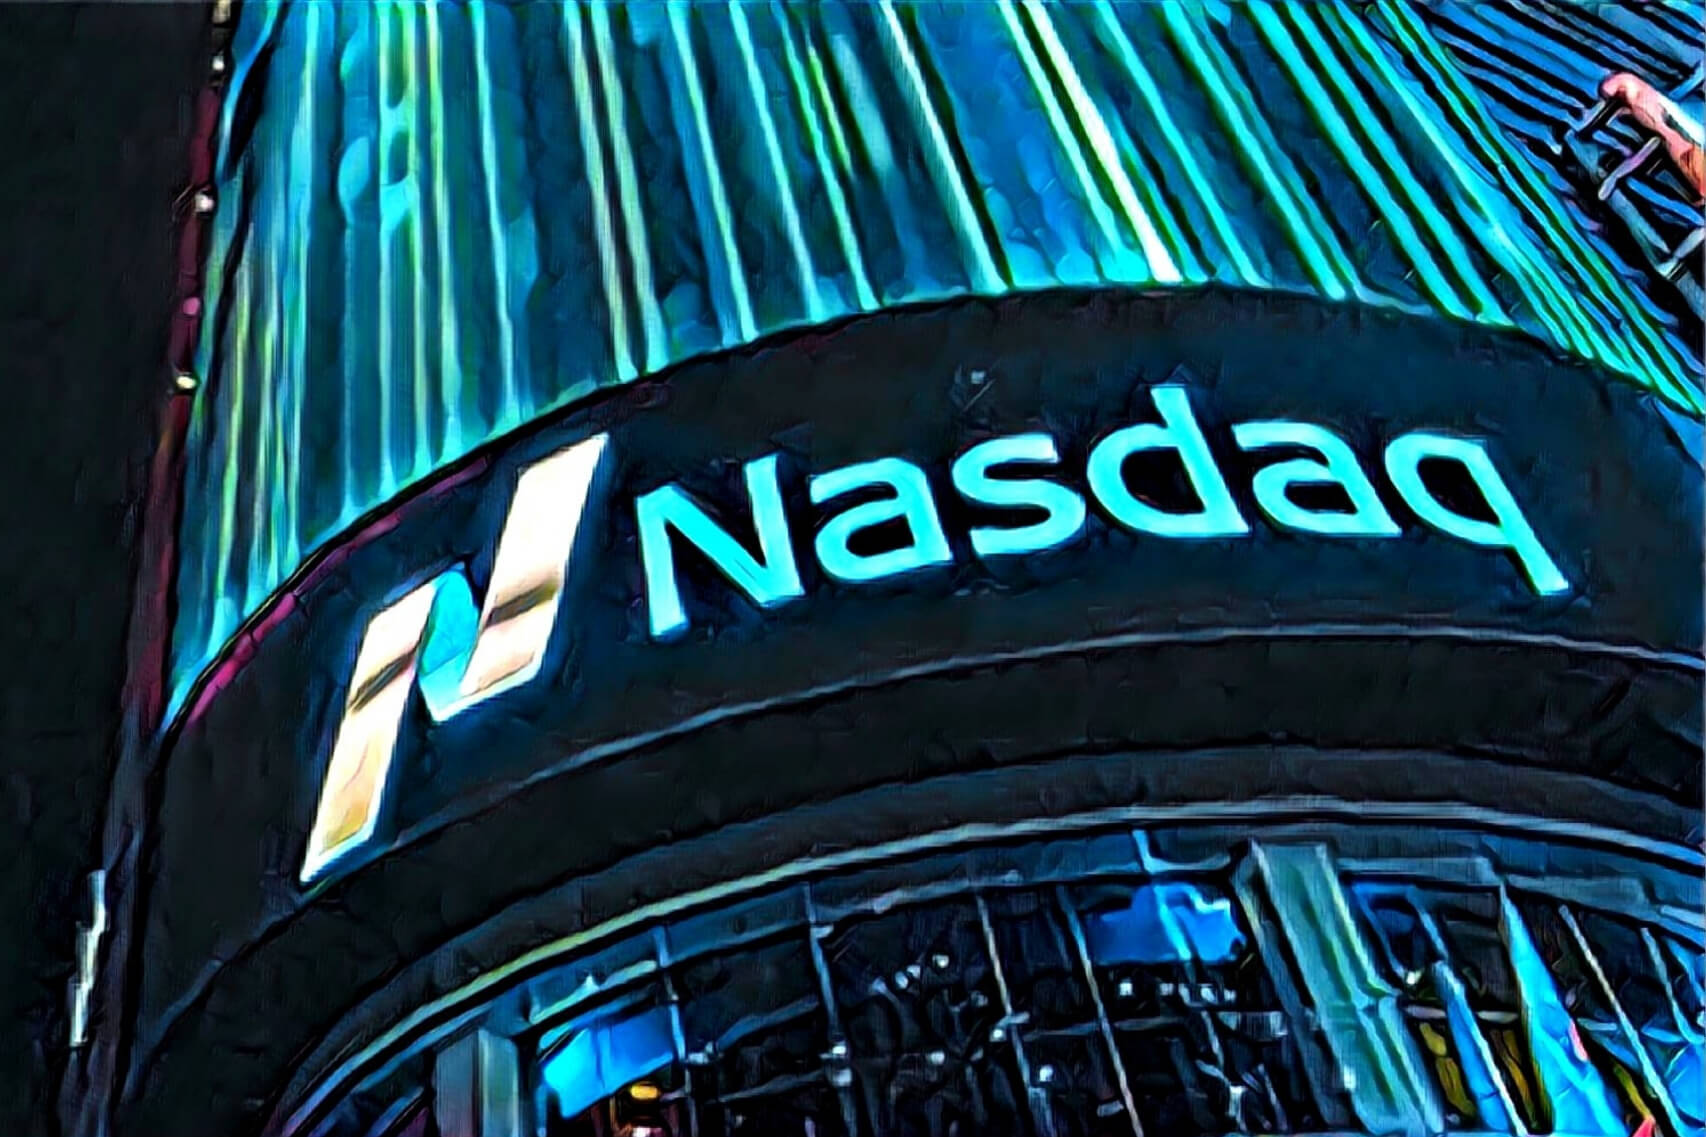

In [2]:
#general
import pandas as pd 
import numpy as np
from scipy import stats
# import imblearn

#preprocessing
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#ML algorithms
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel, VarianceThreshold,SelectKBest
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn.ensemble import RandomForestClassifier #random forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.svm import SVC #SVM
from sklearn.neural_network import MLPClassifier #neural network
from sklearn.naive_bayes import GaussianNB #naive bayes
from sklearn.tree import DecisionTreeClassifier #decision tree

#evaluation
from sklearn.model_selection import learning_curve
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, precision_score, recall_score, roc_auc_score, precision_recall_curve

#ploting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

<h1 align="left"><font color='blue'><font size = 2> 1.1 Exploratory Data Analysis</font></h1><a class='anchor' id='subsection11'></a>

In [13]:
US_df=pd.read_csv('american_data.csv')
US_df.head()
print(US_df.shape)

#check NAN
print(US_df.isnull().values.any())
    #no NAN

#remove outlier
col_names=US_df.columns
def remove_outliers(d,columns,n_std):
    for col in columns:
        # print('Working on column: {}'.format(col))
        mean = d[col].mean()
        sd = d[col].std()
        d = d[(d[col] <= mean+(n_std*sd))]
    return d
US_data=remove_outliers(US_df,col_names[2:],3)
print(US_data.shape)

#browse data
print(round(len(US_df[US_df['status_label']=='alive'])/len(US_df),3),round(len(US_df[US_df['status_label']!='alive'])/len(US_df),3))
        #before removing outliers, 6.6% bankrupted, 93.4% survived
print(round(len(US_data[US_data['status_label']=='alive'])/len(US_data),3),round(len(US_data[US_data['status_label']!='alive'])/len(US_df),3))
        #after removing outliers, 4.9% bankrupted, 93.1% survived
display(US_data.describe())

(78682, 21)

False

(56434, 21)

0.934 0.066

0.931 0.049


,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
count,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000
mean,2006.955754,95.910156,112.796068,9.629794,16.055843,18.790250,-3.996500,26.544697,315.739873,176.032440,205.176816,38.503211,6.425864,63.236519,41.135747,-48.591189,176.032440,94.070297,159.976632
std,5.649395,133.534020,163.999971,19.814067,50.357297,38.940567,58.855512,41.433470,607.577095,237.932847,291.240364,90.011987,45.416701,100.900236,55.958389,434.210609,237.932847,145.936777,207.002030
min,1999.000000,-7.760000,-31.437000,0.000000,-1967.817000,0.000000,-3605.690000,-0.006000,0.000100,-1964.999000,0.001000,-0.023000,-1967.817000,-1964.999000,0.001000,-67264.200000,-1964.999000,0.001000,-31.437000
25%,2002.000000,10.163000,8.530250,0.606250,-2.874000,0.000000,-9.187000,1.517000,19.112325,13.359750,20.010250,0.000000,-5.314000,3.483250,5.268250,-73.591750,13.359750,7.673500,19.086250
50%,2006.000000,42.487000,38.573500,2.887000,2.510500,2.237000,-0.337500,8.721000,84.774600,66.795000,84.381500,1.023500,0.411000,23.009000,17.888500,-10.850500,66.795000,29.135000,68.013000
75%,2012.000000,128.937000,145.779750,10.800750,25.409500,17.399250,7.787750,32.997000,337.950225,247.359000,275.515250,21.702250,14.741750,86.936000,54.903750,23.047500,247.359000,110.325250,221.142250
max,2018.000000,2126.858000,957.174000,711.694000,484.191000,677.500000,551.412000,481.102000,7503.524600,1237.604000,3616.569000,748.271000,259.492000,653.010000,417.431000,1935.671000,1237.604000,791.459000,962.646000


3 ['company_name', 'status_label', 'year']

18 ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18']


Text(0.5, 1.0, 'Correlation Heatmap')

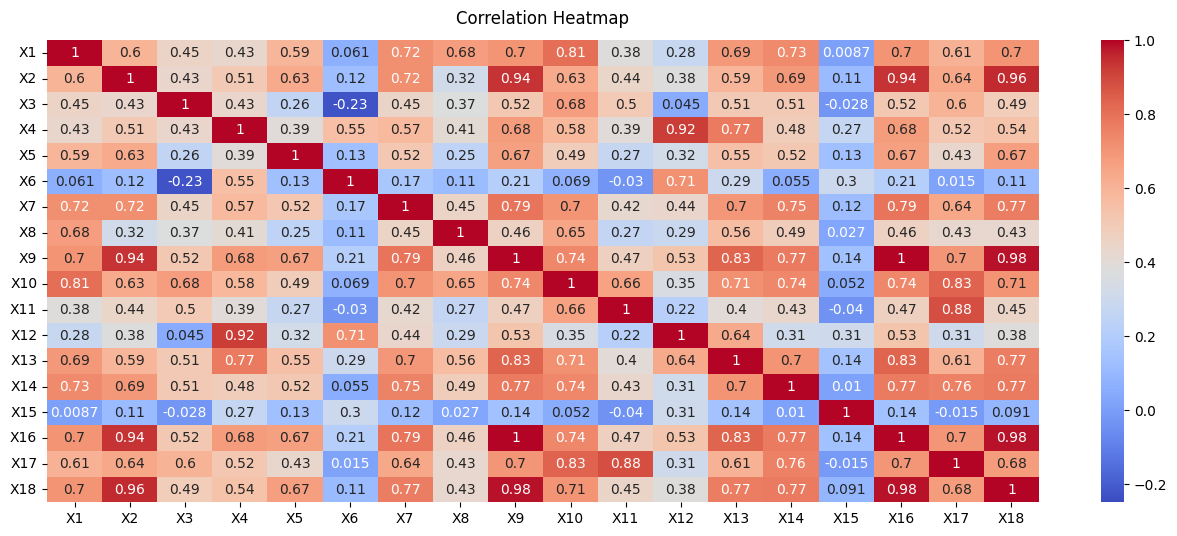

In [14]:
#seperate categorical features from continous features
    # US_data.info()
Cat_col=US_data.select_dtypes(exclude=['float64']).columns
print(len(Cat_col),list(Cat_col))
Num_col=US_data.select_dtypes(include=['float64']).columns
print(len(Num_col),list(Num_col))

#heatmap
plt.figure(figsize=(16, 6))
heatmap_data=US_data.drop(columns=list(Cat_col))
heatmap = sns.heatmap(heatmap_data.corr(), cmap='coolwarm',vmin=-0.25, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12)
    #many are correlated, so use PCA.
        #before PCA, standardize first

<h1 align="left"><font color='blue'><font size = 2> 1.2 Data preprocessing and engineering </font></h1><a class='anchor' id='subsection12'></a>

In [15]:
#standarize data
US_data_stdiz0=US_data.drop(columns=list(Cat_col))
US_data_stdiz0 = (US_data_stdiz0-US_data_stdiz0.mean())/US_data_stdiz0.std()
US_data_stdiz0=pd.merge(US_data[Cat_col],US_data_stdiz0,left_index=True,right_index=True).reset_index()
display(US_data_stdiz0)

# len(US_data_stdiz[US_data_stdiz['status_label']==1])



,index,company_name,status_label,year,X1,X2,X3,X4,X5,X6,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,0,C_1,alive,1999,3.110495,4.392141,0.441263,1.449148,8.146459,0.665350,...,3.565294,1.839790,1.576943,1.414285,1.268476,2.192348,0.574876,3.565294,2.106479,3.745496
1,1,C_1,alive,2000,2.920199,3.664726,0.451558,0.959368,7.750266,0.382759,...,2.934536,1.705386,1.571833,0.866733,0.963402,1.505695,0.581875,2.934536,1.833477,3.139638
2,2,C_1,alive,2001,2.551753,2.522445,0.649347,0.221441,6.877089,-0.933515,...,1.944618,1.734039,1.990799,-0.037758,0.485702,1.953742,0.433417,1.944618,2.096070,2.181319
3,3,C_1,alive,2002,2.250377,2.341165,0.885341,0.291699,6.193124,-0.142952,...,1.808513,1.653082,1.401533,-0.062815,0.459399,2.902858,0.397727,1.808513,2.038984,2.007784
4,4,C_1,alive,2003,2.518413,2.503085,0.860510,0.624242,5.866755,0.127439,...,2.000252,1.730925,2.334831,0.316737,0.648358,1.610576,0.415640,2.000252,2.148449,2.147275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56429,78665,C_8968,alive,2017,-0.693016,-0.686513,-0.483131,-0.530268,-0.482537,-0.117126,...,-0.739618,-0.692592,-0.427756,-0.377171,-0.628259,-0.607304,-0.484856,-0.739618,-0.595390,-0.721136
56430,78677,C_8971,alive,2014,1.028209,-0.423525,0.225305,0.586989,-0.395840,0.497107,...,-0.301805,3.069369,1.623815,0.552553,-0.023305,-0.231221,0.176611,-0.301805,0.903245,-0.489699
56431,78679,C_8971,alive,2016,-0.239184,-0.266598,2.797366,1.250964,-0.416256,0.043403,...,-0.025950,5.291362,7.171065,0.166638,0.372125,0.797544,0.471965,-0.025950,4.633258,-0.334150
56432,78680,C_8971,alive,2017,0.294283,-0.282129,2.811144,1.054766,-0.430842,-0.278725,...,-0.059464,5.256597,7.282717,-0.056914,0.318339,0.730440,0.424983,-0.059464,4.677551,-0.324942


In [16]:
US_data_stdiz0.head(3)
US_data_stdiz0.describe()

,index,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
count,56434.000000,56434.000000,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04,5.643400e+04
mean,42307.212372,2006.955754,6.144254e-17,1.410157e-16,4.734098e-17,2.820314e-17,2.417412e-17,-1.208706e-17,4.935549e-17,-1.410157e-17,-6.647882e-17,5.590264e-17,-6.043529e-17,-8.058039e-18,3.021764e-18,1.379939e-16,6.043529e-18,-6.647882e-17,1.913784e-17,4.331196e-17
std,21825.288281,5.649395,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,0.000000,1999.000000,-7.763576e-01,-8.794701e-01,-4.860079e-01,-3.939594e+01,-4.825366e-01,-6.119552e+01,-6.408031e-01,-5.196703e-01,-8.998469e+00,-7.044896e-01,-4.280120e-01,-4.346953e+01,-2.010140e+01,-7.350953e-01,-1.547996e+02,-8.998469e+00,-6.445894e-01,-9.246945e-01
25%,24891.250000,2002.000000,-6.421372e-01,-6.357673e-01,-4.554110e-01,-3.759106e-01,-4.825366e-01,-8.819055e-02,-6.040454e-01,-4.882138e-01,-6.836916e-01,-6.357861e-01,-4.277565e-01,-2.584922e-01,-5.922015e-01,-6.409673e-01,-5.757704e-02,-6.836916e-01,-5.920152e-01,-6.806232e-01
50%,43494.500000,2006.000000,-4.000715e-01,-4.525767e-01,-3.403034e-01,-2.689847e-01,-4.250901e-01,6.216920e-02,-4.301763e-01,-3.801415e-01,-4.591104e-01,-4.147616e-01,-4.163858e-01,-1.324373e-01,-3.986861e-01,-4.154381e-01,8.691793e-02,-4.591104e-01,-4.449550e-01,-4.442644e-01
75%,60904.750000,2012.000000,2.473291e-01,2.011200e-01,5.909720e-02,1.857458e-01,-3.572109e-02,2.002234e-01,1.557268e-01,3.655561e-02,2.997760e-01,2.415133e-01,-1.866525e-01,1.831019e-01,2.348803e-01,2.460400e-01,1.649860e-01,2.997760e-01,1.113835e-01,2.954832e-01
max,78681.000000,2018.000000,1.520922e+01,5.148647e+00,3.543261e+01,9.296272e+00,1.691577e+01,9.436814e+00,1.097078e+01,1.183024e+01,4.461644e+00,1.171332e+01,7.885259e+00,5.572094e+00,5.845115e+00,6.724555e+00,4.569815e+00,4.461644e+00,4.778704e+00,3.877592e+00


In [17]:
#create a subset for model testing
US_data_stdiz=US_data_stdiz0
US_data_stdiz= US_data_stdiz0.sample(5000,random_state=42) # It's too computationally expensive to run the whole dataset, especially for RF and DT, so I use the subset
# it took over 34 hrs to run the RF modle and still not complete
    #thus I decided to use the subset of 5000 records

# #re-code status_label
US_data_stdiz.loc[US_data_stdiz['status_label']=='alive','status_label']=int(1)
US_data_stdiz.loc[US_data_stdiz['status_label']=='failed','status_label']=int(0)

US_data_stdiz.head(5)

,index,company_name,status_label,year,X1,X2,X3,X4,X5,X6,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
55442,77448,C_8747,1,2014,-0.501461,-0.345568,-0.277065,-0.549391,-0.456060,-0.251438,...,-0.419465,-0.287803,0.003686,-0.488276,-0.427467,0.016249,-0.018758,-0.419465,-0.061351,-0.348492
13124,23612,C_2028,1,1999,0.017021,0.258061,-0.301190,-0.006371,0.333861,0.163477,...,0.238465,-0.157333,-0.243981,0.124341,0.142879,0.498464,0.154607,0.238465,-0.008602,0.275646
40781,59026,C_6322,1,2010,-0.639022,-0.545171,-0.472886,-0.280195,-0.461787,0.052731,...,-0.617420,-0.641844,-0.427756,-0.104364,-0.569835,-0.598530,0.053382,-0.617420,-0.591621,-0.641514
52064,73232,C_8044,1,2011,2.289348,0.633463,1.048558,-0.589246,0.423639,-0.741417,...,0.490410,2.532376,2.532927,-1.110800,0.126823,1.214818,-0.350484,0.490410,2.084661,0.707033
39580,57503,C_6147,1,2005,-0.279166,-0.468921,-0.305379,-0.637243,-0.482537,-0.457859,...,-0.656376,-0.443825,-0.318671,-0.573332,-0.785633,-0.433532,-0.306966,-0.656376,-0.404910,-0.599432


<h1 align="left"><font color='blue'><font size = 2> 1.3 Applying 7 ML algorithms to predict bankruptcy </font></h1><a class='anchor' id='subsection13'></a>

{'algorithm': 'auto', 'n_neighbors': 2, 'weights': 'distance'} KNeighborsClassifier(n_neighbors=2, weights='distance')

Best hyperparameters: {'algorithm': 'auto', 'n_neighbors': 2, 'weights': 'distance'}


,precision,recall,f1-score,support
0,0.155080,0.290000,0.202091,100.0000
1,0.933208,0.862609,0.896521,1150.0000
accuracy,0.816800,0.816800,0.816800,0.8168
macro avg,0.544144,0.576304,0.549306,1250.0000
weighted avg,0.870958,0.816800,0.840966,1250.0000


<Axes: >

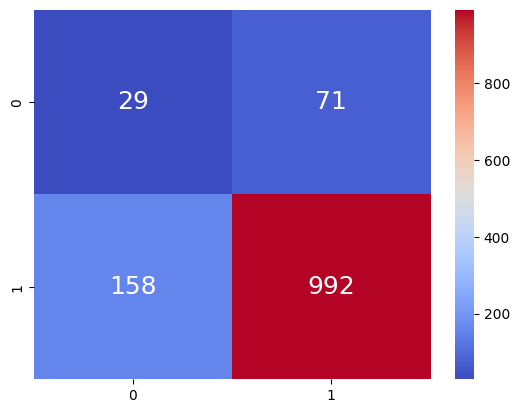

In [18]:
###KNN Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={
        'n_neighbors': np.arange(2,20,5),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

knn_full = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

{'max_depth': 50, 'min_samples_leaf': 1, 'n_estimators': 1000} RandomForestClassifier(max_depth=50, n_estimators=1000)

Best hyperparameters: {'max_depth': 50, 'min_samples_leaf': 1, 'n_estimators': 1000}


,precision,recall,f1-score,support
0,0.272727,0.240000,0.255319,100.000
1,0.934596,0.944348,0.939446,1150.000
accuracy,0.888000,0.888000,0.888000,0.888
macro avg,0.603661,0.592174,0.597383,1250.000
weighted avg,0.881646,0.888000,0.884716,1250.000


<Axes: >

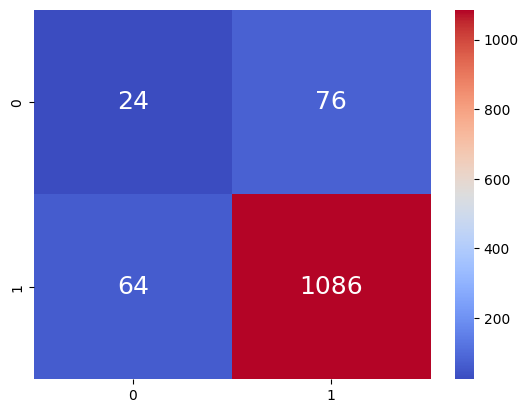

In [19]:
###Random Forest Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'max_depth': [10, 50, 100, None],# 'max_features': ['auto', 'sqrt'],
            'min_samples_leaf': [1, 2, 4],# 'min_samples_split': [2, 5, 10],
            'n_estimators': [10, 100, 1000]} #split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

RF_full = RandomForestClassifier(
            max_depth=best_params['max_depth'],
            # max_features=best_params['max_features'],
            min_samples_leaf=best_params['min_samples_leaf'],
            n_estimators=best_params['n_estimators']
)
RF_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 

400 fits failed out of a total of 720.

The score on these train-test partitions for these parameters will be set to nan.

If these failures are not expected, you can try to debug them by setting error_score='raise'.



Below are more details about the failures:

--------------------------------------------------------------------------------

80 fits failed with the following error:

Traceback (most recent call last):

  File "/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score

    estimator.fit(X_train, y_train, **fit_params)

  File "/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py", line 1162, in fit

    solver = _check_solver(self.solver, self.penalty, self.dual)

             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/Users/enhon

{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'} LogisticRegression(C=100, penalty='l1', solver='liblinear')

Best hyperparameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}


,precision,recall,f1-score,support
0,0.130350,0.670000,0.218241,100.000
1,0.955163,0.611304,0.745493,1150.000
accuracy,0.616000,0.616000,0.616000,0.616
macro avg,0.542757,0.640652,0.481867,1250.000
weighted avg,0.889178,0.616000,0.703313,1250.000


<Axes: >

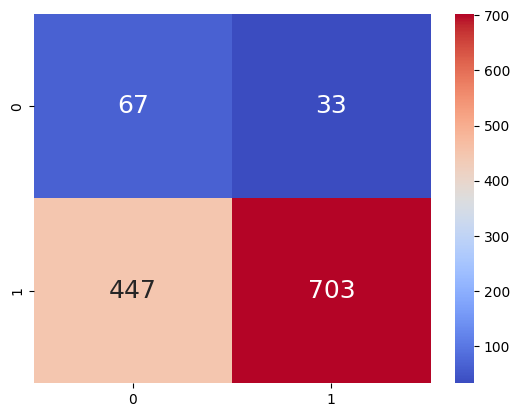

In [33]:
###Logistic Regression Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'solver' : ['newton-cg', 'lbfgs', 'liblinear'],
            'penalty' :['l1', 'l2', 'elasticnet'],
            'C' :[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
            }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

LR_full = LogisticRegression(
            solver= best_params['solver'],
            penalty=best_params['penalty'],
            C=best_params['C']
)
LR_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'} SVC(C=1000, gamma=1)

Best hyperparameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}


,precision,recall,f1-score,support
0,0.130435,0.210000,0.160920,100.0000
1,0.927456,0.878261,0.902188,1150.0000
accuracy,0.824800,0.824800,0.824800,0.8248
macro avg,0.528946,0.544130,0.531554,1250.0000
weighted avg,0.863695,0.824800,0.842887,1250.0000


<Axes: >

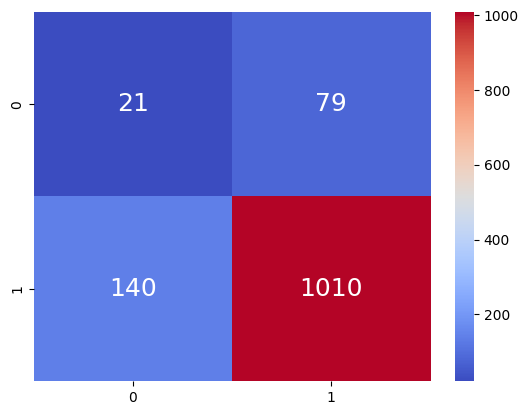

In [21]:
###SVM Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'C': [0.1, 1, 10, 100, 1000], 
            'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
            'kernel': ['linear','rbf']
            }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

svm_full = SVC(
            C= best_params['C'],
            gamma=best_params['gamma'],
            kernel=best_params['kernel']
)
svm_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

{'var_smoothing': 0.0003511191734215131} GaussianNB(var_smoothing=0.0003511191734215131)

Best hyperparameters: {'var_smoothing': 0.0003511191734215131}


,precision,recall,f1-score,support
0,0.082587,0.830000,0.150226,100.0000
1,0.930612,0.198261,0.326882,1150.0000
accuracy,0.248800,0.248800,0.248800,0.2488
macro avg,0.506600,0.514130,0.238554,1250.0000
weighted avg,0.862770,0.248800,0.312749,1250.0000


<Axes: >

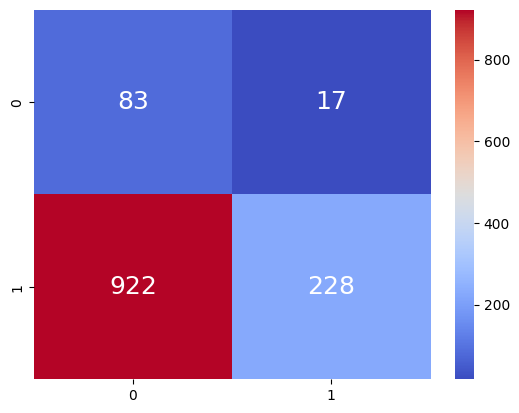

In [22]:
###Naive Bayes Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'var_smoothing': np.logspace(0,-9, num=100)
            }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(GaussianNB(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

NB_full = GaussianNB(
            var_smoothing= best_params['var_smoothing'],
        )
NB_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.

  warnings.warn(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.

  warnings.warn(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.

  warnings.warn(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.

  warnings.warn(

/Users/enhon

{'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (10, 30, 10), 'learning_rate': 'constant', 'solver': 'adam'} MLPClassifier(alpha=0.05, hidden_layer_sizes=(10, 30, 10), max_iter=500)

Best hyperparameters: {'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (10, 30, 10), 'learning_rate': 'constant', 'solver': 'adam'}


/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

  warnings.warn(


,precision,recall,f1-score,support
0,0.152778,0.440000,0.226804,100.00
1,0.941788,0.787826,0.857955,1150.00
accuracy,0.760000,0.760000,0.760000,0.76
macro avg,0.547283,0.613913,0.542379,1250.00
weighted avg,0.878667,0.760000,0.807463,1250.00


<Axes: >

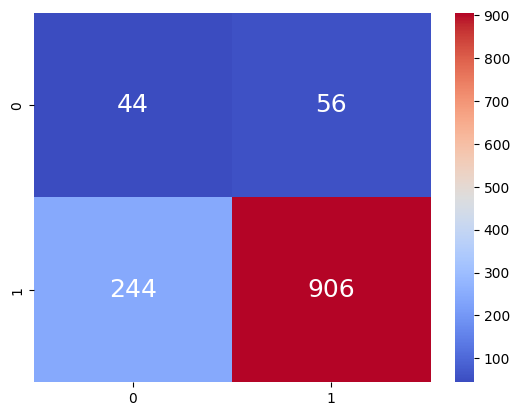

In [23]:
###Neural Network Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid = {
    'hidden_layer_sizes': [(10,30,10),(20,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive']
}
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(MLPClassifier(max_iter=500), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

NN_full = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation= best_params['activation'],
    solver=best_params['solver'],
    alpha=best_params['alpha'],
    learning_rate=best_params['learning_rate']
)
NN_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 

3420 fits failed out of a total of 64980.

The score on these train-test partitions for these parameters will be set to nan.

If these failures are not expected, you can try to debug them by setting error_score='raise'.



Below are more details about the failures:

--------------------------------------------------------------------------------

3420 fits failed with the following error:

Traceback (most recent call last):

  File "/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score

    estimator.fit(X_train, y_train, **fit_params)

  File "/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/tree/_classes.py", line 889, in fit

    super().fit(

  File "/Users/enhongliu/anaconda3/lib/python3.11/site-packages/sklearn/tree/_classes.py", line 177, in fit

    self._validate_params()

 

{'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 3, 'min_samples_split': 5} DecisionTreeClassifier(max_depth=19, min_samples_leaf=3, min_samples_split=5)

Best hyperparameters: {'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 3, 'min_samples_split': 5}


,precision,recall,f1-score,support
0,0.170616,0.360000,0.231511,100.0000
1,0.938402,0.847826,0.890818,1150.0000
accuracy,0.808800,0.808800,0.808800,0.8088
macro avg,0.554509,0.603913,0.561164,1250.0000
weighted avg,0.876979,0.808800,0.838073,1250.0000


<Axes: >

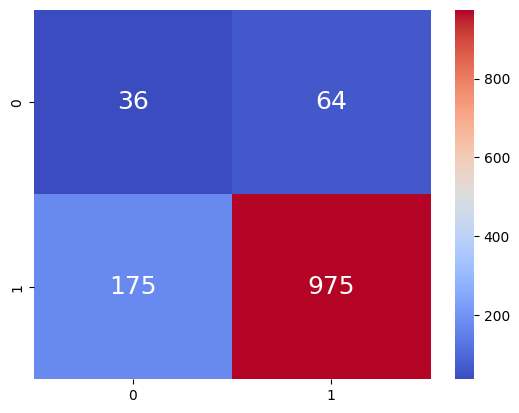

In [24]:
### Decision Tree Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid = {
    "criterion":['gini', 'entropy'],
    "max_depth": range(1,20),
    "min_samples_split": range(1,20),
    "min_samples_leaf": range(1,10)
}
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

DT_full = DecisionTreeClassifier(
    criterion=best_params['criterion'],
    max_depth= best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf']
)
DT_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

In [14]:
results_dict={'Time':['7.1s','70m','17s','562m','2.3s','51m','350m'],\
              'Accuracy':[0.82,0.89,0.62,0.82,0.24,0.76,0.81],\
             'Precision':[0.87,0.88,0.89,0.86,0.86,0.88,0.88],\
             'Recall':[0.82,0.89,0.62,0.82,0.24,0.76,0.81],\
             'F1 Score':[0.84,0.89,0.70,0.84,0.31,0.81,0.84]}
US_results=pd.DataFrame.from_dict(results_dict)
algorithms=['KNN', 'Random Forst','Logistic Regression',\
                        'SVM','Naive Bayes','Neural Networks','Decision Tree']
US_results = US_results.set_index(pd.Index(algorithms))
display(US_results)

,Time,Accuracy,Precision,Recall,F1 Score
KNN,7.1s,0.82,0.87,0.82,0.84
Random Forst,70m,0.89,0.88,0.89,0.89
Logistic Regression,17s,0.62,0.89,0.62,0.70
SVM,562m,0.82,0.86,0.82,0.84
Naive Bayes,2.3s,0.24,0.86,0.24,0.31
Neural Networks,51m,0.76,0.88,0.76,0.81
Decision Tree,350m,0.81,0.88,0.81,0.84


<h1 align="left"><font color='red'size=4>2. Taiwan Area - Deep diving into KNN with PCA and feature selection</font></h1><a class='anchor' id='section2'></a>

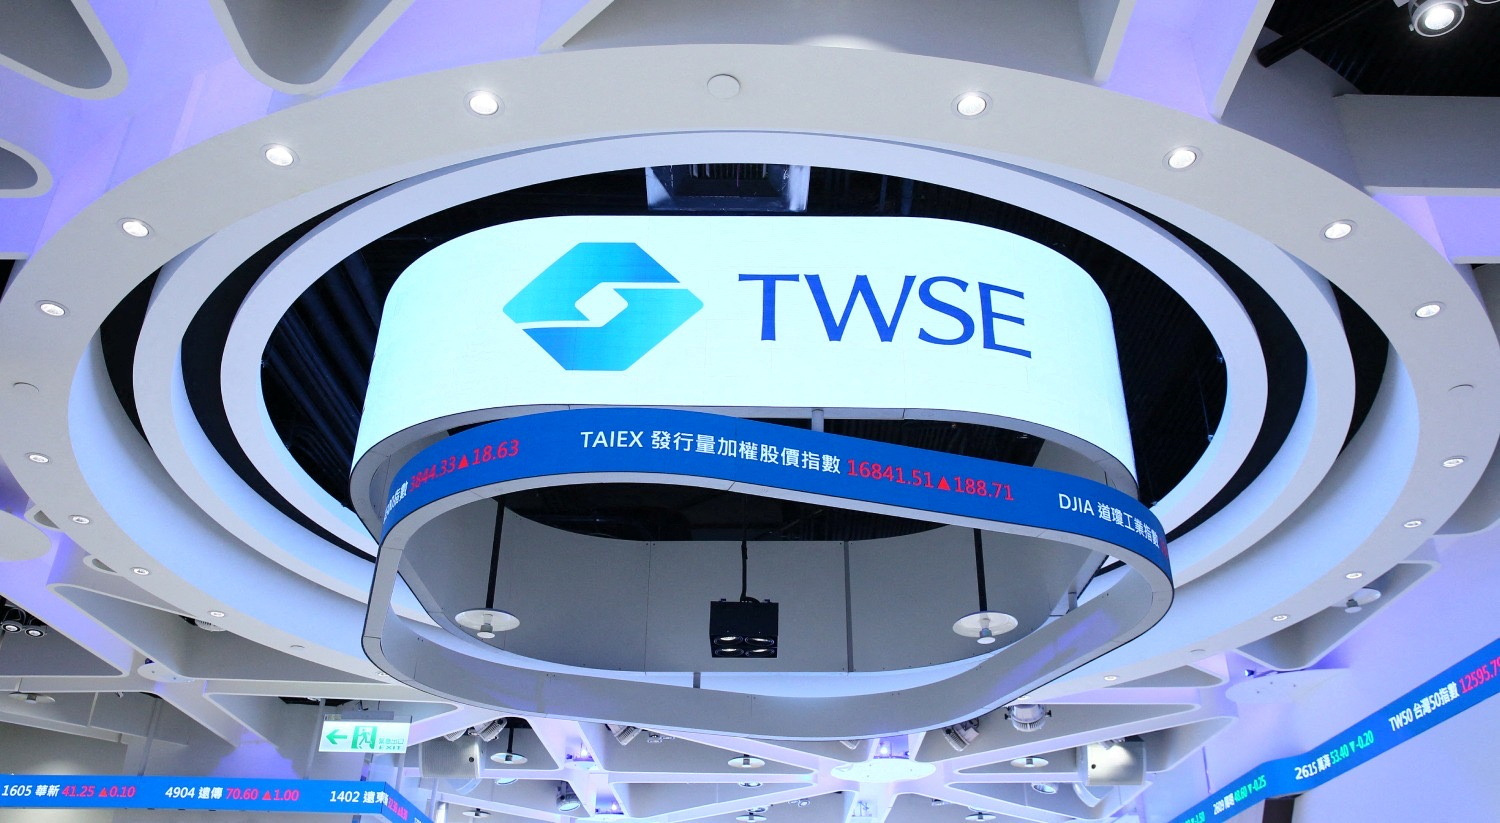

In [15]:
import pandas as pd 
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA,KernelPCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import SelectFromModel, mutual_info_classif, f_classif, SelectKBest
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from matplotlib.colors import ListedColormap
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

<h1 align="left"><font color='blue'><font size = 2> 2.1 Exploratory Data Analysis</font></h1><a class='anchor' id='subsection21'></a>

In [18]:
#read data into dataframe
data=pd.read_csv('/kaggle/input/bankruptcy-datasets/taiwai_area_data.csv')
data.head()

#check NA
print(data.isnull().values.any())
    #no NAN

#decided to not remove outliers

#browse data
print(round(len(data[data['Bankrupt?']==1])/len(data),3),round(len(data[data['Bankrupt?']==0])/len(data),3))
        #before removing outliers, 3.2% bankrupted, 96.8% survived
print(round(len(data[data['Bankrupt?']==1])/len(data),3),round(len(data[data['Bankrupt?']==0])/len(data),3))
        #after removing outliers, 1.4% bankrupted, 98.6% survived
    # thus, need to do over-sampling and under-sampling before model building
display(data.describe())
data.info()

False
0.032 0.968
0.032 0.968


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

<h1 align="left"><font color='blue'><font size = 2> 2.2 Data Preprocessing and Engineering </font></h1><a class='anchor' id='subsection22'></a>

3 ['Bankrupt?', ' Liability-Assets Flag', ' Net Income Flag']
93


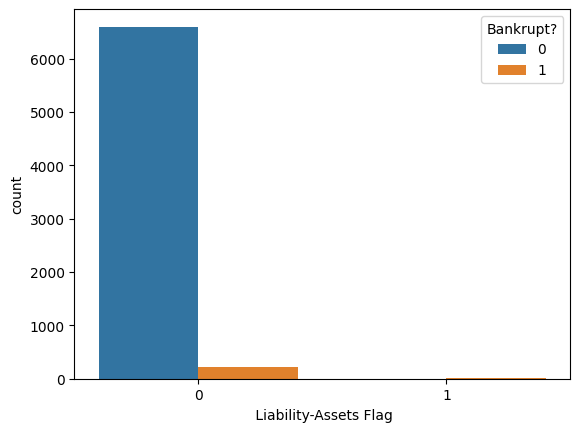

<Axes: xlabel=' Net Income Flag', ylabel='count'>

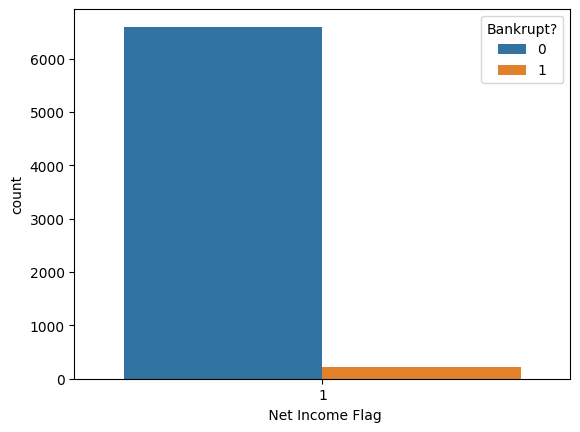

In [19]:
#seperate categorical features from continous features
Cat_col=data.select_dtypes(exclude=['float64']).columns
print(len(Cat_col),list(Cat_col))
    # Liability-Assets Flag: 1 if Total Liability exceeds Total Assets, 0 otherwise
    # Net Income Flag: 1 if Net Income is Negative for the last two years, 0 otherwise
Num_col=data.select_dtypes(exclude=['int64']).columns
print(len(Num_col))

#check 
sns.countplot(x = Cat_col[1],hue = 'Bankrupt?',data = data)
    #bankrupt ==0 => survived, bankrupt ==1 => bankrupted
plt.show()
sns.countplot(x = Cat_col[2],hue = 'Bankrupt?',data = data)

<h1 align="left"><font color='blue'><font size = 2> 2.3 KNN with PCA/Feature Extraction </font></h1><a class='anchor' id='subsection23'></a>

{'algorithm': 'auto', 'n_neighbors': 17, 'weights': 'distance'} KNeighborsClassifier(n_neighbors=17, weights='distance')
Average AUC-ROC score: 0.0
Best hyperparameters: {'algorithm': 'auto', 'n_neighbors': 17, 'weights': 'distance'}


,precision,recall,f1-score,support
0,0.985853,0.797110,0.881491,1661.000000
1,0.069061,0.568182,0.123153,44.000000
accuracy,0.791202,0.791202,0.791202,0.791202
macro avg,0.527457,0.682646,0.502322,1705.000000
weighted avg,0.962193,0.791202,0.861921,1705.000000


<Axes: >

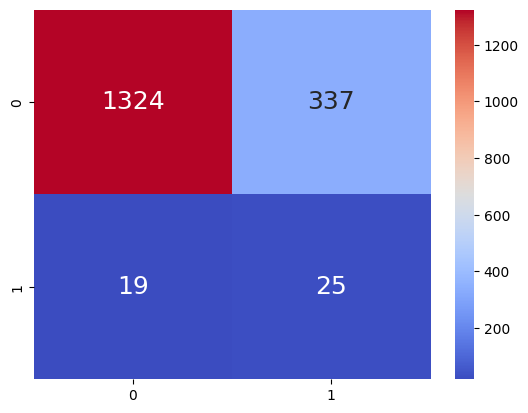

In [20]:
###KNN Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={
        'n_neighbors': np.arange(2,50,3),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
    #split data into training and test
x_train, x_test_full, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=104,test_size=0.25,shuffle=True)

# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#this is right. conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)
# grid_search.fit(x_train_sm, y_train_sm)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Evaluate the best model on the test data
y_pred = best_model.predict(x_test_full)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate AUC-ROC score
auc = roc_auc_score(y_test, y_pred)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Perform cross-validation with the best model
cv_scores = cross_val_score(best_model, x_train, y_train, cv=10, scoring="recall")

# Print average cross-validation score
print("Average AUC-ROC score:", np.mean(cv_scores))

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report

smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

knn_full = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test_full), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test_full)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

/opt/conda/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/conda/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


{'algorithm': 'auto', 'n_neighbors': 5, 'weights': 'distance'}
Average recall score: 0.03986928104575164
Best hyperparameters: {'algorithm': 'auto', 'n_neighbors': 5, 'weights': 'distance'}


,precision,recall,f1-score,support
0,0.990623,0.890427,0.937857,1661.000000
1,0.141509,0.681818,0.234375,44.000000
accuracy,0.885044,0.885044,0.885044,0.885044
macro avg,0.566066,0.786123,0.586116,1705.000000
weighted avg,0.968710,0.885044,0.919702,1705.000000


<Axes: >

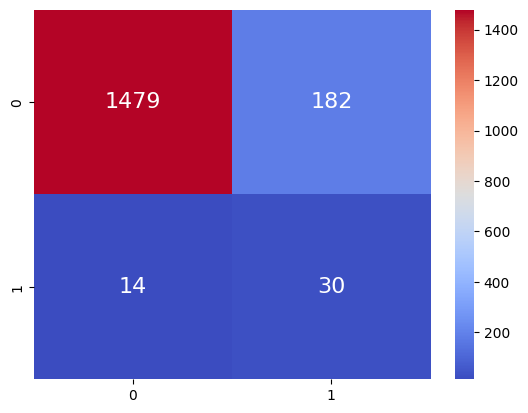

In [21]:
###KNN Model with features selection with smote

# Define the parameter grid for the entire pipeline
param_grid={
        'n_neighbors': np.arange(2,50,3),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
#split data into training and test
x_train, x_test_features, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=104,test_size=0.25,shuffle=True)

#select top XX features
feature_selection=SelectKBest(f_classif,k=30).fit(x_train,y_train)
selected_features=x_train.columns[feature_selection.get_support()]

#oversampling for unbalanced data
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train[selected_features],y_train)

# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

# Fit the pipeline with hyperparameter tuning on the training data
grid_search.fit(x_train_sm, y_train_sm)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params)

# Evaluate the best model on the test data
y_pred = best_model.predict(x_test_features[selected_features])

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate AUC-ROC score
auc = roc_auc_score(y_test, y_pred)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Perform cross-validation with the best model
cv_scores = cross_val_score(best_model, x_train, y_train, cv=10, scoring="recall")

# Print average cross-validation score
print("Average recall score:", np.mean(cv_scores))

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
knn_features = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_features.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, knn_features.predict(x_test_features[selected_features]), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,knn_features.predict(x_test_features[selected_features])), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':16})

PCA explained variation: [0.22160954 0.37761011 0.50392439 0.62555042 0.73455458 0.82626741
 0.91251745 0.98000377 0.98472585 0.98875408 0.99199032 0.99406105
 0.99527664 0.99632974 0.99726966 0.99809005 0.99864013 0.9991657
 0.99940485 0.99961977]
{'algorithm': 'auto', 'n_neighbors': 2, 'weights': 'distance'}
Average recall score: 0.11862745098039214
Best hyperparameters: {'algorithm': 'auto', 'n_neighbors': 2, 'weights': 'distance'}


,precision,recall,f1-score,support
0,0.977664,0.922336,0.949195,1661.000000
1,0.065217,0.204545,0.098901,44.000000
accuracy,0.903812,0.903812,0.903812,0.903812
macro avg,0.521441,0.563441,0.524048,1705.000000
weighted avg,0.954117,0.903812,0.927251,1705.000000


<Axes: >

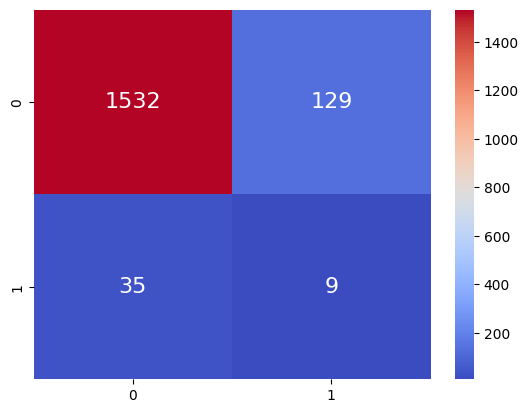

In [23]:
#### KNN with linear PCA and smote

#split into training and test data
x_train, x_test_PCA, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=104,test_size=0.25,shuffle=True)

#linear PCA 
pca = PCA(n_components = 20,random_state=104)
pca.fit(x_train)
x_train_pca = pca.transform(x_train)
x_test_lpca=pca.transform(x_test_PCA)
print ('PCA explained variation:',pca.explained_variance_ratio_.cumsum())


param_grid={
        'n_neighbors': np.arange(2,50,3),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }

#oversampling for unbalanced data
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train_pca,y_train)

# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

# Fit the pipeline with hyperparameter tuning on the training data
grid_search.fit(x_train_pca, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params)

# Evaluate the best model on the test data
y_pred = best_model.predict(x_test_lpca)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate AUC-ROC score
auc = roc_auc_score(y_test, y_pred)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Perform cross-validation with the best model
cv_scores = cross_val_score(best_model, x_train_pca, y_train, cv=10, scoring="recall")

# Print average cross-validation score
print("Average recall score:", np.mean(cv_scores))

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
knn_lpca = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_lpca.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, knn_lpca.predict(x_test_lpca), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,knn_lpca.predict(x_test_lpca)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':16})

{'algorithm': 'auto', 'n_neighbors': 2, 'weights': 'uniform'}
Average recall score: 0.1
Best hyperparameters: {'algorithm': 'auto', 'n_neighbors': 2, 'weights': 'uniform'}


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
0,0.974194,1.000000,0.986928,1661.000000
1,0.000000,0.000000,0.000000,44.000000
accuracy,0.974194,0.974194,0.974194,0.974194
macro avg,0.487097,0.500000,0.493464,1705.000000
weighted avg,0.949053,0.974194,0.961459,1705.000000


<Axes: >

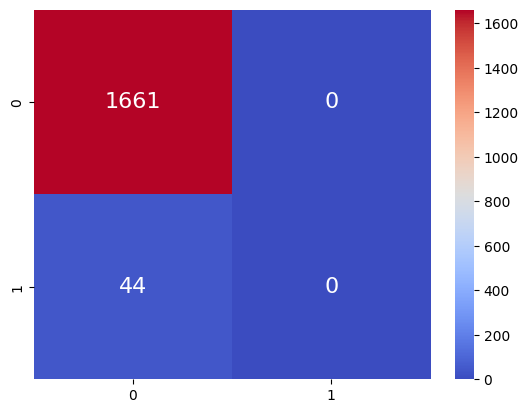

In [24]:
#### KNN with sigmoid PCA and smote

#split into training and test data
x_train, x_test_PCA, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=104,test_size=0.25,shuffle=True)

#sigmoid PCA 
pca = KernelPCA(n_components = 20,kernel='sigmoid',random_state=104)
pca.fit(x_train)
x_train_pca = pca.transform(x_train)
x_test_sigmoidpca=pca.transform(x_test_PCA)


param_grid={
        'n_neighbors': np.arange(2,50,3),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }

#oversampling for unbalanced data
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train_pca,y_train)

# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

# Fit the pipeline with hyperparameter tuning on the training data
grid_search.fit(x_train_pca, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params)

# Evaluate the best model on the test data
y_pred = best_model.predict(x_test_sigmoidpca)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate AUC-ROC score
auc = roc_auc_score(y_test, y_pred)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Perform cross-validation with the best model
cv_scores = cross_val_score(best_model, x_train_pca, y_train, cv=10, scoring="recall")

# Print average cross-validation score
print("Average recall score:", np.mean(cv_scores))

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
knn_sigmoidpca = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_sigmoidpca.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, knn_sigmoidpca.predict(x_test_sigmoidpca), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,knn_sigmoidpca.predict(x_test_sigmoidpca)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':16})

{'algorithm': 'ball_tree', 'n_neighbors': 2, 'weights': 'distance'}
Average recall score: 0.09542483660130717
Best hyperparameters: {'algorithm': 'ball_tree', 'n_neighbors': 2, 'weights': 'distance'}


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
0,0.974194,1.000000,0.986928,1661.000000
1,0.000000,0.000000,0.000000,44.000000
accuracy,0.974194,0.974194,0.974194,0.974194
macro avg,0.487097,0.500000,0.493464,1705.000000
weighted avg,0.949053,0.974194,0.961459,1705.000000


<Axes: >

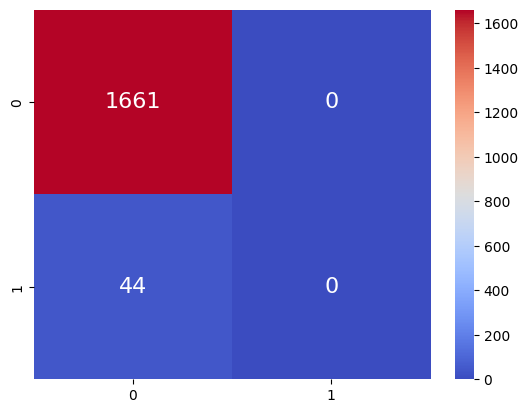

In [25]:
#### KNN with rbf PCA and smote

#split into training and test data
x_train, x_test_PCA, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=104,test_size=0.25,shuffle=True)

#rbf PCA 
pca = KernelPCA(n_components = 20,kernel='rbf',random_state=104)
pca.fit(x_train)
x_train_pca = pca.transform(x_train)
x_test_rbfpca=pca.transform(x_test_PCA)


param_grid={
        'n_neighbors': np.arange(2,50,3),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }

#oversampling for unbalanced data
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train_pca,y_train)

# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

# Fit the pipeline with hyperparameter tuning on the training data
grid_search.fit(x_train_pca, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params)

# Evaluate the best model on the test data
y_pred = best_model.predict(x_test_rbfpca)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate AUC-ROC score
auc = roc_auc_score(y_test, y_pred)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Perform cross-validation with the best model
cv_scores = cross_val_score(best_model, x_train_pca, y_train, cv=10, scoring="recall")

# Print average cross-validation score
print("Average recall score:", np.mean(cv_scores))

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
knn_rbfpca = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_rbfpca.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, knn_rbfpca.predict(x_test_rbfpca), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,knn_rbfpca.predict(x_test_rbfpca)), cmap='coolwarm',fmt='d',annot=True,annot_kws={'size':16})

In [26]:
results_dict={'Accuracy':[0.79,0.89,0.90,0.97,0.97],\
             'Precision':[0.96,0.97,0.95,0.95,0.95],\
             'Recall':[0.79,0.89,0.91,0.97,0.97],\
             'F1 Score':[0.86,0.92,0.93,0.97,0.96]}
Taiwan_results=pd.DataFrame.from_dict(results_dict)
algorithms=['KNN','KNN with Feature Extraction','KNN with Linear PCA',\
            'KNN with Sigmoid PCA','KNN with rbf PCA']
Taiwan_results = Taiwan_results.set_index(pd.Index(algorithms))
display(Taiwan_results)

,Accuracy,Precision,Recall,F1 Score
KNN,0.79,0.96,0.79,0.86
KNN with Feature Extraction,0.89,0.97,0.89,0.92
KNN with Linear PCA,0.90,0.95,0.91,0.93
KNN with Sigmoid PCA,0.97,0.95,0.97,0.97
KNN with rbf PCA,0.97,0.95,0.97,0.96


<h1 align="left"><font color='red'size=4>3. Conclusions </font></h1><a class='anchor' id='section3'></a>

The analysis and modeling efforts have provided valuable insights into predicting bankruptcies in companies. By leveraging advanced techniques in machine learning, and KNN, we can determine that random forest best captured complexities in the data and predicted bankruptcy more accurately, while KNN can also be a good option when taking computation time into account. The focus on recall rate as a critical criterion when building models ensures the accurate identification of bankruptcies, vital for financial analysis. 

Moving forward, I would recommend incorporating industry labels and temporal context to enhance model accuracy and generalizability. Moreover, further improvements, including outlier removal techniques, predictor reduction, and exploration of unsupervised models, will refine the predictions. Addressing imbalanced data and fine-tuning model selection through sample scenarios will also contribute to more robust and relevant bankruptcy predictions, empowering better decision-making in this dynamic landscape.